<a href="https://colab.research.google.com/github/rupjyotibasu890-byte/API-Data-Fetching/blob/main/TFD_MODEL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [50]:
from scapy.all import rdpcap
import numpy as np
from google.colab import files
from IPython.display import clear_output
import pandas as pd # Added for CSV processing
import csv # Added for CSV processing


# ----------- SET YOUR TRAINING DATA SOURCE HERE -----------
training_data_file = '/content/NT.csv' # <--- CHANGE THIS TO YOUR NEW CSV FILE PATH for training
training_data_type = 'csv' # 'pcap' or 'csv'
# --- CSV SPECIFIC COLUMN MAPPING (UPDATE THESE IF YOUR CSV HAS DIFFERENT HEADERS) ---
csv_timestamp_column_name = 0 # e.g., 'Time', 'Timestamp', 'Packet Time'
csv_size_column_name = 3 # e.g., 'Length', 'Frame Length', 'Size'
print(f"Using {training_data_type} file for training: {training_data_file}")


# ----------- FEATURE EXTRACTION FROM PCAP (EXISTING) -----------
def extract_features_from_pcap(pcap_file):
    packets = rdpcap(pcap_file)

    features = []
    prev_time = None

    for pkt in packets:
        timestamp = float(pkt.time)
        size = len(pkt)

        if prev_time is None:
            iat = 0.0
        else:
            iat = timestamp - prev_time

        features.append([iat, size])
        prev_time = timestamp

    return np.array(features, dtype=np.float32)

# ----------- FEATURE EXTRACTION FROM CSV (NEW) -----------
def extract_features_from_csv(csv_file_path, timestamp_col_name, size_col_name):
    # Load the CSV file into a pandas DataFrame, assuming no header row
    mixed_df = pd.read_csv(csv_file_path, sep=',', header=None, engine='python', skipinitialspace=True, encoding='latin1', on_bad_lines='skip')

    # Use user-specified column indices for timestamp and size
    # Check if the column indices are within the DataFrame's bounds
    if not (0 <= timestamp_col_name < mixed_df.shape[1]) or not (0 <= size_col_name < mixed_df.shape[1]):
        raise KeyError(f"Required column indices '{timestamp_col_name}' and '{size_col_name}' are out of bounds for a CSV with {mixed_df.shape[1]} columns. Please update 'csv_timestamp_column_name' and 'csv_size_column_name' variables to match your CSV structure.")

    # Create consistent column names for internal processing
    mixed_df['timestamp'] = mixed_df[timestamp_col_name]
    mixed_df['size'] = mixed_df[size_col_name]

    # Convert timestamp to numeric and calculate IAT
    mixed_df['timestamp'] = pd.to_numeric(mixed_df['timestamp'], errors='coerce')
    mixed_df['iat'] = mixed_df['timestamp'].diff().fillna(0) # Calculate Inter-Arrival Time

    # Define parse_size_column function
    def parse_size_column(size_value):
        if isinstance(size_value, str):
            if '0x' in size_value:
                hex_part = size_value.split(',')[0].replace('0x', '')
                try:
                    return int(hex_part, 16)
                except ValueError:
                    return np.nan
            else:
                try:
                    return float(size_value)
                except ValueError:
                    return np.nan
        return size_value

    # Convert 'size' to numeric, handling potential hex values
    mixed_df['size'] = mixed_df['size'].apply(parse_size_column)

    # Drop rows where 'timestamp', 'iat' or 'size' calculation resulted in NaN
    mixed_df.dropna(subset=['timestamp', 'iat', 'size'], inplace=True)

    if mixed_df.empty:
        print("Warning: DataFrame is empty after dropping NaN values. Returning empty sequences.")
        return np.array([], dtype=np.float32).reshape(0, 2)

    feature_columns = ['iat', 'size']
    features = mixed_df[feature_columns].values.astype(np.float32)
    features = np.nan_to_num(features, nan=np.nanmean(features, axis=0)) # Fill NaNs potentially introduced by parsing
    if np.isnan(features).any(): # Re-check if NaNs still exist after initial fill (e.g., if a column was all NaN)
        features = np.nan_to_num(features, nan=0.0) # Fill remaining NaNs with 0.0

    return features

# ----------- NORMALIZATION (EXISTING) -----------
def normalize_features(features, mean=None, std=None):
    if mean is None:
        mean = features.mean(axis=0)
    if std is None:
        std = features.std(axis=0) + 1e-8

    return (features - mean) / std, mean, std


# ----------- SEQUENCE CREATION (EXISTING) -----------
def create_sequences(features, seq_len=16):
    sequences = []
    for i in range(len(features) - seq_len):
        sequences.append(features[i:i + seq_len])
    return np.array(sequences, dtype=np.float32)


# ----------- FULL PIPELINE (MODIFIED TO ACCEPT DATA TYPE) -----------
def preprocessing_pipeline(data_source, data_type='pcap', seq_len=16, mean=None, std=None, csv_timestamp_col_name=None, csv_size_col_name=None):
    if data_type == 'pcap':
        features = extract_features_from_pcap(data_source)
    elif data_type == 'csv':
        if csv_timestamp_col_name is None or csv_size_col_name is None:
            raise ValueError("csv_timestamp_col_name and csv_size_col_name must be provided for CSV data_type.")
        features = extract_features_from_csv(data_source, csv_timestamp_col_name, csv_size_col_name)
    else:
        raise ValueError("Unsupported data_type. Must be 'pcap' or 'csv'.")

    if features.shape[0] == 0: # Handle case where no features were extracted
        print("Warning: No features extracted. Returning empty sequences.")
        return np.array([], dtype=np.float32), None, None

    features, mean, std = normalize_features(features, mean, std)
    sequences = create_sequences(features, seq_len)
    return sequences, mean, std


# ----------- RUN TRAINING PREPROCESSING -----------
sequences, mean, std = preprocessing_pipeline(
    training_data_file,
    training_data_type,
    csv_timestamp_col_name=csv_timestamp_column_name,
    csv_size_col_name=csv_size_column_name
)

print("Output shape:", sequences.shape)

Using csv file for training: /content/NT.csv
Output shape: (2705338, 16, 2)


In [49]:
import pandas as pd

# Assuming training_data_file is defined as '/content/NT.csv'
try:
    temp_df = pd.read_csv(training_data_file, sep=',', header=0, engine='python', skipinitialspace=True, encoding='latin1', on_bad_lines='skip')
    print(f"Columns in {training_data_file}:\n{temp_df.columns.tolist()}")
except FileNotFoundError:
    print(f"Error: The file {training_data_file} was not found.")
except Exception as e:
    print(f"An error occurred while reading the CSV: {e}")

Columns in /content/NT.csv:
['1777321333.034238100', 'Unnamed: 1', 'Unnamed: 2', '145']


In [5]:
!pip install scapy

from scapy.all import rdpcap
import numpy as np
from google.colab import files
from IPython.display import clear_output


# ----------- SET YOUR FILE PATH HERE / UPLOAD PCAP FILE -----------
pcap_file = '/content/normalt2.pcap' # <--- CHANGE THIS TO YOUR NEW PCAP FILE PATH
print(f"Using PCAP file from Colab filesystem: {pcap_file}")


# ----------- FEATURE EXTRACTION -----------
def extract_features_from_pcap(pcap_file):
    packets = rdpcap(pcap_file)

    features = []
    prev_time = None

    for pkt in packets:
        timestamp = float(pkt.time)
        size = len(pkt)

        if prev_time is None:
            iat = 0.0
        else:
            iat = timestamp - prev_time

        features.append([iat, size])
        prev_time = timestamp

    return np.array(features, dtype=np.float32)


# ----------- NORMALIZATION -----------
def normalize_features(features, mean=None, std=None):
    if mean is None:
        mean = features.mean(axis=0)
    if std is None:
        std = features.std(axis=0) + 1e-8

    return (features - mean) / std, mean, std


# ----------- SEQUENCE CREATION -----------
def create_sequences(features, seq_len=16):
    sequences = []
    for i in range(len(features) - seq_len):
        sequences.append(features[i:i + seq_len])
    return np.array(sequences, dtype=np.float32)


# ----------- FULL PIPELINE -----------
def preprocessing_pipeline(pcap_file, seq_len=16, mean=None, std=None):
    features = extract_features_from_pcap(pcap_file)
    features, mean, std = normalize_features(features, mean, std)
    sequences = create_sequences(features, seq_len)
    return sequences, mean, std


# ----------- RUN -----------
sequences, mean, std = preprocessing_pipeline(pcap_file)

print("Output shape:", sequences.shape)


Using PCAP file from Colab filesystem: /content/normalt2.pcap
Output shape: (27979, 16, 2)


### TFD Model Architecture

First, let's re-define the `TimeDomainAutoencoder`, `FrequencyDomainAutoencoder`, and the `TFDModel` classes that were previously in the notebook. This model combines both time-domain (LSTM) and frequency-domain (CNN) autoencoders for robust feature learning.

In [6]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


# ------------------ Time-Domain Reconstructor ------------------
class TimeDomainAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.lstm1 = nn.LSTM(2, 32, batch_first=True)
        self.lstm2 = nn.LSTM(32, 8, batch_first=True)

        self.lstm3 = nn.LSTM(8, 8, batch_first=True)
        self.lstm4 = nn.LSTM(8, 32, batch_first=True)

        self.fc = nn.Linear(32, 2)

    def forward(self, x):
        x, _ = self.lstm1(x)
        _, (h, _) = self.lstm2(x)

        x = h.squeeze(0)
        x = x.unsqueeze(1).repeat(1, 16, 1)

        x, _ = self.lstm3(x)
        x, _ = self.lstm4(x)

        x = self.fc(x)
        return x


# ------------------ Residual Block (Frequency) ------------------
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv1d(channels, channels, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv1d(channels, channels, kernel_size=3, padding=1)

    def forward(self, x):
        residual = x
        x = self.relu(self.conv1(x))
        x = self.conv2(x)
        return self.relu(x + residual)


# ------------------ Frequency-Domain Reconstructor ------------------
class FrequencyDomainAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv_in = nn.Conv1d(2, 32, kernel_size=3, padding=1)

        self.resblock1 = ResidualBlock(32)
        self.resblock2 = ResidualBlock(32)
        self.resblock3 = ResidualBlock(32)

        self.conv_out = nn.Conv1d(32, 2, kernel_size=3, padding=1)

    def forward(self, x):
        # x: (batch, 16, 2) → (batch, 2, 16)
        x = x.permute(0, 2, 1)

        x = self.conv_in(x)

        x = self.resblock1(x)
        x = self.resblock2(x)
        x = self.resblock3(x)

        x = self.conv_out(x)

        # back to (batch, 16, 2)
        x = x.permute(0, 2, 1)
        return x


# ------------------ Full TFD Model ------------------
class TFDModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.time_model = TimeDomainAutoencoder()
        self.freq_model = FrequencyDomainAutoencoder()

    def forward(self, x):
        time_out = self.time_model(x)
        freq_out = self.freq_model(x)
        return time_out, freq_out

In [7]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Instantiate the TFD Model
model = TFDModel()

# Define Loss Function and Optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Convert numpy sequences to PyTorch tensors and create a DataLoader
train_data = torch.tensor(sequences, dtype=torch.float32)
train_dataset = TensorDataset(train_data)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

print("TFD Model instantiated.")
print(f"Number of training sequences: {len(train_dataset)}")

TFD Model instantiated.
Number of training sequences: 27979


### Model Instantiation and Training Setup

Now, let's instantiate the `TFDModel`, define the loss function (Mean Squared Error is common for autoencoders) and an optimizer (Adam), and prepare the data for training.

In [51]:
# Instantiate the TFD Model
model = TFDModel()

# Define Loss Function and Optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Convert numpy sequences to PyTorch tensors and create a DataLoader
train_data = torch.tensor(sequences, dtype=torch.float32)
train_dataset = TensorDataset(train_data)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

print("TFD Model instantiated.")
print(f"Number of training sequences: {len(train_dataset)}")

TFD Model instantiated.
Number of training sequences: 2705338


### Training Loop

This is a basic training loop. You can adjust the number of `epochs` and monitor the `loss` to determine when to stop training. The goal is to minimize the reconstruction error for both the time-domain and frequency-domain autoencoders.

In [53]:
num_epochs = 15

for epoch in range(num_epochs):
    model.train() # Set model to training mode
    total_loss = 0
    for batch_idx, (data,) in enumerate(train_loader):
        optimizer.zero_grad()

        time_reconstructed, freq_reconstructed = model(data)

        # Calculate loss for both autoencoders
        time_loss = criterion(time_reconstructed, data)
        freq_loss = criterion(freq_reconstructed, data)

        # Combine losses (you might want to weigh them differently)
        loss = time_loss + freq_loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')
print("Training complete.")

KeyboardInterrupt: 

### Anomaly Detection: Establishing a Threshold

In [10]:
model.eval() # Set model to evaluation mode
reconstruction_errors = []

with torch.no_grad(): # Disable gradient calculation
    for (data,) in train_loader:
        time_reconstructed, freq_reconstructed = model(data)

        time_loss = torch.mean(torch.sum((time_reconstructed - data)**2, dim=[1,2]), dim=0)
        freq_loss = torch.mean(torch.sum((freq_reconstructed - data)**2, dim=[1,2]), dim=0)

        # Total loss for each sequence in the batch
        batch_loss = (torch.sum((time_reconstructed - data)**2, dim=[1,2]) + torch.sum((freq_reconstructed - data)**2, dim=[1,2]))
        reconstruction_errors.extend(batch_loss.cpu().numpy())

reconstruction_errors = np.array(reconstruction_errors)
print(f"Calculated {len(reconstruction_errors)} reconstruction errors for normal data.")
print(f"Mean reconstruction error: {np.mean(reconstruction_errors):.4f}")
print(f"Max reconstruction error: {np.max(reconstruction_errors):.4f}")

Calculated 27979 reconstruction errors for normal data.
Mean reconstruction error: 6.6828
Max reconstruction error: 342.4086


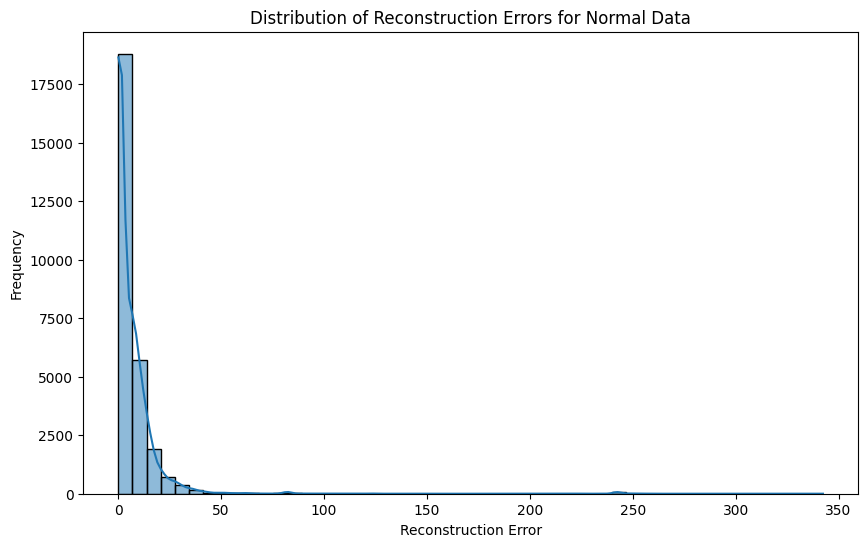

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the distribution of reconstruction errors
plt.figure(figsize=(10, 6))
sns.histplot(reconstruction_errors, bins=50, kde=True)
plt.title('Distribution of Reconstruction Errors for Normal Data')
plt.xlabel('Reconstruction Error')
plt.ylabel('Frequency')
plt.show()

Based on the distribution of reconstruction errors for normal data, we can now set a threshold. A common approach is to use a percentile (e.g., 95th or 99th percentile) or a multiple of the mean/standard deviation. For this example, let's set a simple threshold using the 95th percentile.

In [12]:
threshold = np.percentile(reconstruction_errors, 95) # 95th percentile as a simple threshold
print(f"Anomaly Threshold (95th percentile): {threshold:.4f}")

# Let's also define a function to calculate the combined reconstruction error for a single sequence
def calculate_combined_reconstruction_error(model, sequence):
    model.eval()
    with torch.no_grad():
        sequence_tensor = torch.tensor(sequence, dtype=torch.float32).unsqueeze(0) # Add batch dimension
        time_reconstructed, freq_reconstructed = model(sequence_tensor)

        time_error = torch.sum((time_reconstructed - sequence_tensor)**2).item()
        freq_error = torch.sum((freq_reconstructed - sequence_tensor)**2).item()

        return time_error + freq_error

Anomaly Threshold (95th percentile): 21.6307


### Anomaly Detection on New Data (e.g., Attack Data)

In [14]:
# ----------- SET YOUR ATTACK FILE PATH HERE -----------
attack_pcap_file = '/content/attack_syn.pcap'
print(f"Using attack PCAP file from Colab filesystem: {attack_pcap_file}")

# Preprocess the attack data using the same pipeline and normalization parameters
attack_sequences, _, _ = preprocessing_pipeline(attack_pcap_file, mean=mean, std=std)

print(f"Attack data sequences shape: {attack_sequences.shape}")

Using attack PCAP file from Colab filesystem: /content/attack_syn.pcap
Attack data sequences shape: (4333, 16, 2)


In [15]:
attack_reconstruction_errors = []

for i in range(len(attack_sequences)):
    sequence = attack_sequences[i]
    error = calculate_combined_reconstruction_error(model, sequence)
    attack_reconstruction_errors.append(error)

attack_reconstruction_errors = np.array(attack_reconstruction_errors)

print(f"Calculated {len(attack_reconstruction_errors)} reconstruction errors for attack data.")
print(f"Mean reconstruction error for attack data: {np.mean(attack_reconstruction_errors):.4f}")
print(f"Max reconstruction error for attack data: {np.max(attack_reconstruction_errors):.4f}")

Calculated 4333 reconstruction errors for attack data.
Mean reconstruction error for attack data: 89.6160
Max reconstruction error for attack data: 1012.2822


Total attack sequences: 4333
Number of detected anomalies: 1102
Anomaly detection rate: 25.43%
Classification: Attack detected in PCAP file!
Detection results logged to /content/anomaly_detection_history.csv


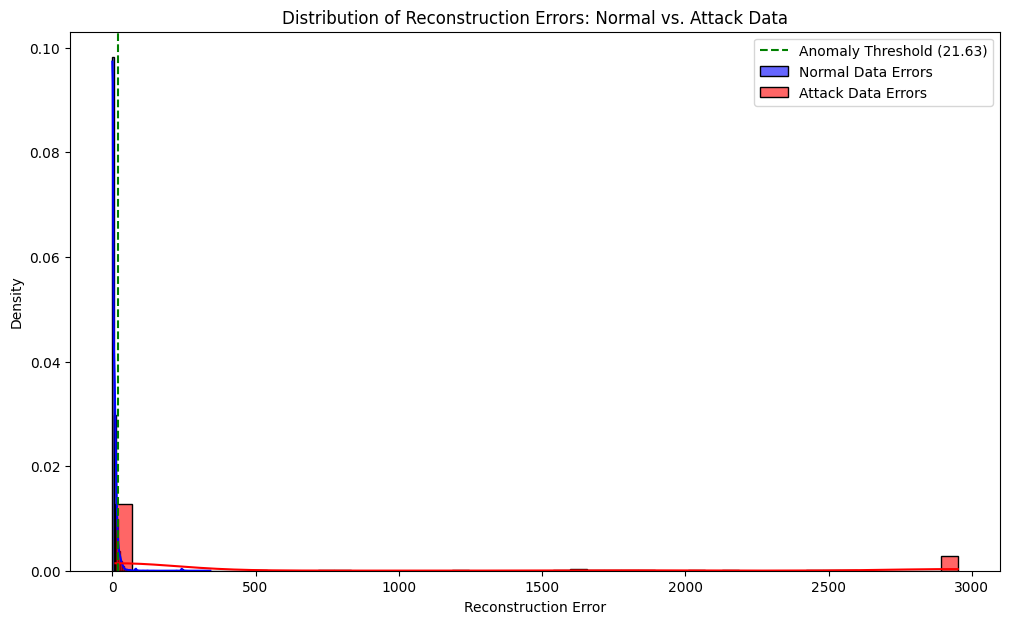

In [21]:
import torch
import torch.nn as nn

# ------------------ Time-Domain Reconstructor ------------------
class TimeDomainAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.lstm1 = nn.LSTM(2, 32, batch_first=True)
        self.lstm2 = nn.LSTM(32, 8, batch_first=True)

        self.lstm3 = nn.LSTM(8, 8, batch_first=True)
        self.lstm4 = nn.LSTM(8, 32, batch_first=True)

        self.fc = nn.Linear(32, 2)

    def forward(self, x):
        x, _ = self.lstm1(x)
        _, (h, _) = self.lstm2(x)

        x = h.squeeze(0)
        x = x.unsqueeze(1).repeat(1, 16, 1)

        x, _ = self.lstm3(x)
        x, _ = self.lstm4(x)

        x = self.fc(x)
        return x


# ------------------ Residual Block (Frequency) ------------------
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv1d(channels, channels, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv1d(channels, channels, kernel_size=3, padding=1)

    def forward(self, x):
        residual = x
        x = self.relu(self.conv1(x))
        x = self.conv2(x)
        return self.relu(x + residual)


# ------------------ Frequency-Domain Reconstructor ------------------
class FrequencyDomainAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv_in = nn.Conv1d(2, 32, kernel_size=3, padding=1)

        self.resblock1 = ResidualBlock(32)
        self.resblock2 = ResidualBlock(32)
        self.resblock3 = ResidualBlock(32)

        self.conv_out = nn.Conv1d(32, 2, kernel_size=3, padding=1)

    def forward(self, x):
        # x: (batch, 16, 2) → (batch, 2, 16)
        x = x.permute(0, 2, 1)

        x = self.conv_in(x)

        x = self.resblock1(x)
        x = self.resblock2(x)
        x = self.resblock3(x)

        x = self.conv_out(x)

        # back to (batch, 16, 2)
        x = x.permute(0, 2, 1)
        return x


# ------------------ Full TFD Model ------------------
class TFDModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.time_model = TimeDomainAutoencoder()
        self.freq_model = FrequencyDomainAutoencoder()

    def forward(self, x):
        time_out = self.time_model(x)
        freq_out = self.freq_model(x)
        return time_out, freq_out

# Recalculate attack_reconstruction_errors here to ensure it's defined
# This step is duplicated from a previous cell (00ed7272) to handle cases
# where that cell might not have been executed or the runtime was reset.
attack_reconstruction_errors = []

# Re-instantiate the model and load its weights, ensuring it's available
# The TFDModel class must be defined in an earlier cell for this to work.
model = TFDModel() # Instantiate the model
model.load_state_dict(torch.load('/content/tfd_model.pth')) # Load the saved weights

# Ensure model is in evaluation mode
model.eval()

with torch.no_grad(): # Disable gradient calculation
    for i in range(len(attack_sequences)):
        sequence = attack_sequences[i]
        error = calculate_combined_reconstruction_error(model, sequence)
        attack_reconstruction_errors.append(error)

attack_reconstruction_errors = np.array(attack_reconstruction_errors)

# Classify anomalies based on the threshold
anomalies = attack_reconstruction_errors > threshold
num_anomalies = np.sum(anomalies)

detection_rate_pcap = (num_anomalies / len(attack_reconstruction_errors) * 100)

print(f"Total attack sequences: {len(attack_reconstruction_errors)}")
print(f"Number of detected anomalies: {num_anomalies}")
print(f"Anomaly detection rate: {detection_rate_pcap:.2f}%")

# Provide a simple 'Attack' or 'Normal' classification for PCAP
if num_anomalies > 0:
    print("Classification: Attack detected in PCAP file!")
else:
    print("Classification: Normal traffic in PCAP file.")

# Log the PCAP detection results
log_detection_results('PCAP', attack_pcap_file, num_anomalies, len(attack_reconstruction_errors), detection_rate_pcap)

# Visualize the distribution of reconstruction errors for attack data vs. normal data
plt.figure(figsize=(12, 7))
sns.histplot(reconstruction_errors, bins=50, kde=True, color='blue', label='Normal Data Errors', stat='density', alpha=0.6)
sns.histplot(attack_reconstruction_errors, bins=50, kde=True, color='red', label='Attack Data Errors', stat='density', alpha=0.6)
plt.axvline(threshold, color='green', linestyle='--', label=f'Anomaly Threshold ({threshold:.2f})')
plt.title('Distribution of Reconstruction Errors: Normal vs. Attack Data')
plt.xlabel('Reconstruction Error')
plt.ylabel('Density')
plt.legend()
plt.show()

### Saving the Trained Model

In [18]:
model_save_path = '/content/tfd_model.pth'
torch.save(model.state_dict(), model_save_path)
print(f"TFD Model saved successfully to {model_save_path}")

TFD Model saved successfully to /content/tfd_model.pth


### Anomaly Detection on a Mixed Synthetic Dataset (CSV)

First, we'll load your CSV file, assuming it contains columns for 'iat' (Inter-Arrival Time) and 'size' (packet size). Please update the `csv_file_path` and `feature_columns` variables if your file has a different name or column headers.

In [42]:
import pandas as pd
import numpy as np # Ensure numpy is imported for nan
import csv # Import csv module for QUOTE_NONE

# ----------- SET YOUR PCAP FILE PATH HERE -----------
pcap_file = '/content/normalt2.pcap' # <--- CHANGE THIS TO YOUR NEW PCAP FILE PATH
print(f"Using PCAP file from Colab filesystem: {pcap_file}")


# ----------- FEATURE EXTRACTION -----------
def extract_features_from_pcap(pcap_file):
    packets = rdpcap(pcap_file)

    features = []
    prev_time = None

    for pkt in packets:
        timestamp = float(pkt.time)
        size = len(pkt)

        if prev_time is None:
            iat = 0.0
        else:
            iat = timestamp - prev_time

        features.append([iat, size])
        prev_time = timestamp

    return np.array(features, dtype=np.float32)


# ----------- NORMALIZATION -----------
def normalize_features(features, mean=None, std=None):
    if mean is None:
        mean = features.mean(axis=0)
    if std is None:
        std = features.std(axis=0) + 1e-8

    return (features - mean) / std, mean, std


# ----------- SEQUENCE CREATION -----------
def create_sequences(features, seq_len=16):
    sequences = []
    for i in range(len(features) - seq_len):
        sequences.append(features[i:i + seq_len])
    return np.array(sequences, dtype=np.float32)


# ----------- FULL PIPELINE -----------
def preprocessing_pipeline(pcap_file, seq_len=16, mean=None, std=None):
    features = extract_features_from_pcap(pcap_file)
    features, mean, std = normalize_features(features, mean, std)
    sequences = create_sequences(features, seq_len)
    return sequences, mean, std


# ----------- RUN -----------
sequences, mean, std = preprocessing_pipeline(pcap_file)

print("Output shape:", sequences.shape)


# ----------- SET YOUR CSV FILE PATH HERE -----------
csv_file_path = '/content/normaltrafficdissection.csv'  # <--- UPDATED TO YOUR NEW CSV FILE PATH
print(f"Using mixed dataset from Colab filesystem: {csv_file_path}")

# ----------- ASSUMED FEATURE COLUMNS -----------
# Update these if your CSV uses different column names for IAT and Size
feature_columns = ['iat', 'size']

# Load the CSV file into a pandas DataFrame
try:
    # Assuming comma-separated values and header row based on kernel state inspection
    # Removed quoting=csv.QUOTE_NONE to allow pandas to automatically handle quoted fields
    mixed_df = pd.read_csv(csv_file_path, sep=',', header=0, engine='python', skipinitialspace=True, encoding='latin1', on_bad_lines='skip')
    print(f"Successfully loaded {len(mixed_df)} rows from {csv_file_path}")
    print(f"Original columns read: {mixed_df.columns.tolist()}")

    # Rename columns to a consistent format for IAT and Size extraction
    # Assuming 'Time' column is the timestamp and 'Length' is the packet size
    # Adjust these names based on actual header of your CSV if different
    if 'Time' in mixed_df.columns:
        mixed_df.rename(columns={'Time': 'timestamp'}, inplace=True)
    if 'Length' in mixed_df.columns:
        mixed_df.rename(columns={'Length': 'size'}, inplace=True)
    # If 'size' column is named something else like 'Frame Length'
    elif 'Frame Length' in mixed_df.columns:
        mixed_df.rename(columns={'Frame Length': 'size'}, inplace=True)

    # Ensure 'timestamp' and 'size' columns exist after renaming (or are original names)
    if 'timestamp' not in mixed_df.columns or 'size' not in mixed_df.columns:
        raise KeyError("Required columns 'Time' (or 'timestamp') and 'Length' (or 'size') not found in CSV. Please update the column mapping or verify your CSV content.")

    # Convert timestamp to numeric and calculate IAT
    mixed_df['timestamp'] = pd.to_numeric(mixed_df['timestamp'], errors='coerce')
    mixed_df['iat'] = mixed_df['timestamp'].diff().fillna(0) # Calculate Inter-Arrival Time

    # Define parse_size_column function (moved inside try block to be defined before use)
    def parse_size_column(size_value):
        if isinstance(size_value, str):
            # Handle values like '0x0002,id', '0x0011,0', etc.
            if '0x' in size_value:
                hex_part = size_value.split(',')[0].replace('0x', '')
                try:
                    return int(hex_part, 16) # Convert hexadecimal to integer
                except ValueError:
                    return np.nan # Return NaN for unparseable hex values
            else:
                # Try converting other strings directly to float (e.g., if some are just numbers as strings)
                try:
                    return float(size_value)
                except ValueError:
                    return np.nan # Return NaN for other unparseable strings
        return size_value # Return as is if already a number (int/float)

    # Convert 'size' to numeric, handling potential hex values if not already numeric
    mixed_df['size'] = mixed_df['size'].apply(parse_size_column)

    print(f"Shape before dropping NaNs: {mixed_df.shape}")
    print(f"NaNs in timestamp before dropna: {mixed_df['timestamp'].isnull().sum()}")
    print(f"NaNs in iat before dropna: {mixed_df['iat'].isnull().sum()}")
    print(f"NaNs in size before dropna: {mixed_df['size'].isnull().sum()}")

    # Drop rows where 'timestamp', 'iat' or 'size' calculation resulted in NaN
    mixed_df.dropna(subset=['timestamp', 'iat', 'size'], inplace=True)

    print(f"Shape after dropping NaNs: {mixed_df.shape}")

    if mixed_df.empty:
        print("Warning: DataFrame is empty after dropping NaN values. Please check data quality or preprocessing steps.")
        # Handle the empty DataFrame case gracefully, e.g., by skipping further processing
        mixed_features = np.array([], dtype=np.float32).reshape(0, 2)
        mixed_sequences = np.array([], dtype=np.float32)
        print(f"Extracted features of shape: {mixed_features.shape}")
        print(f"Mixed data sequences shape: {mixed_sequences.shape}")
    else:
        print(f"Processed columns available for features: {mixed_df.columns.tolist()}")

        # Extract the features as a NumPy array
        try:
            mixed_features = mixed_df[feature_columns].values.astype(np.float32)
            print(f"Extracted features of shape: {mixed_features.shape}")
        except KeyError as e:
            print(f"Error: Missing expected feature column: {e}. Please ensure 'iat' and 'size' are correctly derived/available in the DataFrame.")
            raise

        # --- NEW: Fill any NaN values that might have been introduced during parsing in either feature column ---
        mixed_features = np.nan_to_num(mixed_features, nan=np.nanmean(mixed_features, axis=0)) # This line will now only execute if mixed_features is not empty
        # If mixed_features still contains NaNs (e.g., if a column is entirely NaN), fill with 0 or a sensible default
        if np.isnan(mixed_features).any():
            print("Warning: NaN values still present after initial fill. Filling remaining NaNs with 0.")
            mixed_features = np.nan_to_num(mixed_features, nan=0.0)
        # --- END NEW ---

        # Normalize the features using the mean and std from the normal training data
        mixed_normalized_features, _, _ = normalize_features(mixed_features, mean=mean, std=std);

        # Create sequences from the normalized features
        mixed_sequences = create_sequences(mixed_normalized_features, seq_len=16)

        print(f"Mixed data sequences shape: {mixed_sequences.shape}")


except FileNotFoundError:
    print(f"Error: CSV file not found at {csv_file_path}. Please check the path.")
    raise # Re-raise the exception to stop execution
except Exception as e:
    print(f"Error reading CSV or processing data: {e}. Please check file format, separator, and assigned column names.")
    raise


Using PCAP file from Colab filesystem: /content/normalt2.pcap
Output shape: (27979, 16, 2)
Using mixed dataset from Colab filesystem: /content/normaltrafficdissection.csv
Successfully loaded 16821 rows from /content/normaltrafficdissection.csv
Original columns read: ['No.', 'Time', 'Source', 'Destination', 'Protocol', 'Length', 'Info']
Shape before dropping NaNs: (16821, 8)
NaNs in timestamp before dropna: 0
NaNs in iat before dropna: 0
NaNs in size before dropna: 0
Shape after dropping NaNs: (16821, 8)
Processed columns available for features: ['No.', 'timestamp', 'Source', 'Destination', 'Protocol', 'size', 'Info', 'iat']
Extracted features of shape: (16821, 2)
Mixed data sequences shape: (16805, 16, 2)


Now, we will calculate the reconstruction errors for each sequence in the mixed dataset using our trained TFD model.

In [43]:
import multiprocessing
import torch
import numpy as np # Ensure numpy is imported

# The TFDModel class and calculate_combined_reconstruction_error function
# are assumed to be defined in previous cells and are accessible in the global scope.
# model_save_path is also defined in a previous cell.

def _worker_calculate_errors_for_chunk(sequences_chunk, model_path):
    # This function runs in a separate process, so it needs to
    # re-instantiate the model and load its state.
    local_model = TFDModel() # TFDModel must be defined in parent process's global scope
    local_model.load_state_dict(torch.load(model_path))
    local_model.eval()

    chunk_errors = []
    with torch.no_grad():
        for sequence in sequences_chunk:
            # calculate_combined_reconstruction_error must also be defined in parent process's global scope
            error = calculate_combined_reconstruction_error(local_model, sequence)
            chunk_errors.append(error)
    return chunk_errors

# Ensure model_save_path is accessible (it was defined in dbcdf6c9)
model_save_path = '/content/tfd_model.pth'

# Number of processes to use. It's usually good to use cpu_count() or cpu_count() - 1
num_processes = multiprocessing.cpu_count() - 1 if multiprocessing.cpu_count() > 1 else 1
print(f"Using {num_processes} processes for anomaly detection.")

# Split mixed_sequences into chunks for parallel processing
# Using np.array_split for even distribution
chunks = np.array_split(mixed_sequences, num_processes)

all_reconstruction_errors = []

# Use a multiprocessing Pool
with multiprocessing.Pool(processes=num_processes) as pool:
    # Use starmap to pass multiple arguments to the worker function
    # model_save_path is constant for all workers
    results = pool.starmap(_worker_calculate_errors_for_chunk, [(chunk, model_save_path) for chunk in chunks])

    # Combine results from all processes
    for res_list in results:
        all_reconstruction_errors.extend(res_list)

mixed_reconstruction_errors = np.array(all_reconstruction_errors)

print(f"Calculated {len(mixed_reconstruction_errors)} reconstruction errors for the mixed dataset.")
print(f"Mean reconstruction error for mixed data: {np.mean(mixed_reconstruction_errors):.4f}")
print(f"Max reconstruction error for mixed data: {np.max(mixed_reconstruction_errors):.4f}")

Using 1 processes for anomaly detection.
Calculated 16805 reconstruction errors for the mixed dataset.
Mean reconstruction error for mixed data: 126.4851
Max reconstruction error for mixed data: 7291.0588


Finally, we will classify anomalies based on the established threshold and visualize the distribution of errors.

Total sequences in mixed dataset: 16805
Number of detected anomalies: 10669
Anomaly detection rate: 63.49%
Classification: Attack detected!


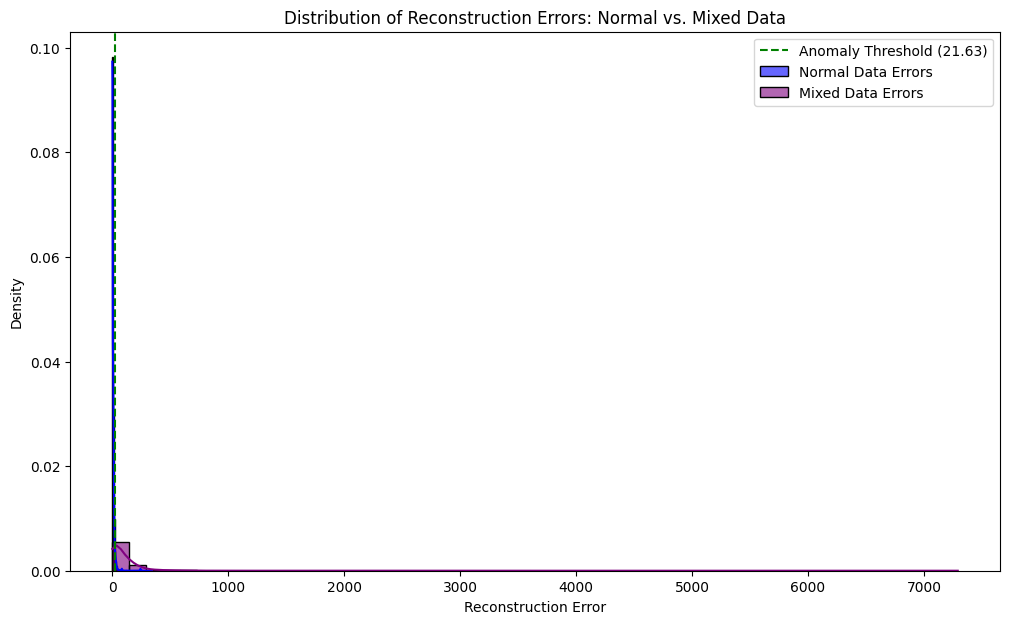

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Classify anomalies based on the threshold
anomalies_in_mixed_data = mixed_reconstruction_errors > threshold
num_anomalies_mixed = np.sum(anomalies_in_mixed_data)

print(f"Total sequences in mixed dataset: {len(mixed_reconstruction_errors)}")
print(f"Number of detected anomalies: {num_anomalies_mixed}")
print(f"Anomaly detection rate: {(num_anomalies_mixed / len(mixed_reconstruction_errors) * 100):.2f}%")

# Provide a simple 'Attack' or 'Normal' classification
if num_anomalies_mixed > 0:
    print("Classification: Attack detected!")
else:
    print("Classification: Normal traffic.")

# Visualize the distribution of reconstruction errors for mixed data vs. normal data
plt.figure(figsize=(12, 7))
sns.histplot(reconstruction_errors, bins=50, kde=True, color='blue', label='Normal Data Errors', stat='density', alpha=0.6)
sns.histplot(mixed_reconstruction_errors, bins=50, kde=True, color='purple', label='Mixed Data Errors', stat='density', alpha=0.6)
plt.axvline(threshold, color='green', linestyle='--', label=f'Anomaly Threshold ({threshold:.2f})')
plt.title('Distribution of Reconstruction Errors: Normal vs. Mixed Data')
plt.xlabel('Reconstruction Error')
plt.ylabel('Density')
plt.legend()
plt.show()

### Anomaly Detection History

This section logs the anomaly detection rates for each PCAP and CSV file processed, allowing you to track performance over time. The results are stored in a local CSV file, which will be deleted if the Colab runtime is reset.

In [45]:
import pandas as pd
import datetime
import os

log_file_path = '/content/anomaly_detection_history.csv'

def log_detection_results(file_type, file_name, num_anomalies, total_sequences, detection_rate):
    global log_file_path # Ensure we use the global path

    timestamp = datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    new_entry = pd.DataFrame([{
        'Timestamp': timestamp,
        'File Type': file_type,
        'File Name': file_name,
        'Detected Anomalies': num_anomalies,
        'Total Sequences': total_sequences,
        'Detection Rate (%)': f'{detection_rate:.2f}'
    }])

    if os.path.exists(log_file_path):
        history_df = pd.read_csv(log_file_path)
        history_df = pd.concat([history_df, new_entry], ignore_index=True)
    else:
        history_df = new_entry

    history_df.to_csv(log_file_path, index=False)
    print(f"Detection results logged to {log_file_path}")

print("Anomaly detection logging utility defined.")

Anomaly detection logging utility defined.
